## 1. 라이브러리 & 데이터 로딩

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ✅ 파일명 수정 (언더바 사용)
data = pd.read_csv('서울시 성동구 휴게음식점 인허가 정보.csv', encoding='EUC-KR')
print("총 데이터 수:", len(data))
data.head()

총 데이터 수: 1175


,개방자치단체코드,관리번호,인허가일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,전화번호,소재지면적,...,공장판매직종업원수,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지
0,3030000,3030000-104-2019-00062,2019-05-02,3,폐업,2,폐업,2020-08-14,NaN,62.80,...,NaN,NaN,NaN,NaN,NaN,N,62.80,NaN,NaN,NaN
1,3030000,3030000-104-2021-00058,2021-04-23,3,폐업,2,폐업,2025-06-30,NaN,35.96,...,NaN,NaN,NaN,NaN,NaN,N,35.96,NaN,NaN,NaN
2,3030000,3030000-104-2018-00082,2018-05-23,3,폐업,2,폐업,2022-08-12,NaN,93.73,...,NaN,NaN,NaN,NaN,NaN,N,93.73,NaN,NaN,NaN
3,3030000,3030000-104-2020-00160,2020-12-08,1,영업/정상,1,영업,,NaN,52.29,...,NaN,NaN,NaN,NaN,NaN,N,52.29,NaN,NaN,NaN
4,3030000,3030000-104-2020-00164,2020-12-09,1,영업/정상,1,영업,,NaN,35.00,...,NaN,NaN,NaN,NaN,NaN,N,35.00,NaN,NaN,NaN


## 2. 전처리 & 프랜차이즈 분류

In [3]:
cols = ['사업장명', '상세영업상태명', '인허가일자', '폐업일자', '도로명주소', '좌표정보(X)', '좌표정보(Y)']
data = data[cols].copy()

# 날짜 변환
data['인허가일자'] = pd.to_datetime(data['인허가일자'], errors='coerce')
data['폐업일자']  = pd.to_datetime(data['폐업일자'],  errors='coerce')

# ✅ 프랜차이즈 키워드 수정 (실제 데이터 기준)
franchise_keywords = {
    '스타벅스': '스타벅스',
    '메가커피':  '메가엠지씨',   # ✅ 수정: '메가엠지씨커피' 실제 이름
    '컴포즈':   '컴포즈',
    '빽다방':   '빽다방',
    '투썸':     '투썸플레이스',  # ✅ 수정: '투썸플레이스' 실제 이름
}

def classify(name):
    for brand, keyword in franchise_keywords.items():
        if keyword in str(name):
            return brand
    return '개인카페'

data['브랜드'] = data['사업장명'].apply(classify)

# 브랜드별 수량 확인
print(data['브랜드'].value_counts())

브랜드
개인카페    1102
메가커피      21
스타벅스      19
컴포즈       12
빽다방       11
투썸        10
Name: count, dtype: int64


## 3. 브랜드별 추출

In [8]:
# 스타벅스
starbucks = data[data['브랜드'] == '스타벅스'].copy()
print(f"성동구 스타벅스 총 {len(starbucks)}개")
print(starbucks[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

성동구 스타벅스 총 19개
               사업장명 상세영업상태명      인허가일자       폐업일자
96          스타벅스 성수      영업 2022-02-21        NaT
97        스타벅스 뚝섬역점      폐업 2017-11-06 2021-03-03
317         스타벅스 옥수      영업 2021-09-01        NaT
460       스타벅스 성수역점      폐업 2017-07-18 2024-11-20
560     스타벅스 상왕십리역점      영업 2017-01-11        NaT
663     스타벅스 황학사거리점      영업 2017-04-13        NaT
751     스타벅스  성수낙낙점      영업 2020-09-24        NaT
774       스타벅스 뚝섬역점      폐업 2017-11-06 2021-03-03
860    스타벅스왕십리엔터식스점      폐업 2008-09-09 2012-04-30
926       스타벅스-한양대점      영업 2001-04-17        NaT
937     스타벅스 성수이마트점      폐업 2008-12-16 2023-04-26
973      스타벅스 왕십리역점      영업 2015-04-23        NaT
975       스타벅스 신금호역      영업 2022-12-08        NaT
978   스타벅스 왕십리역9번출구      영업 2022-11-07        NaT
1006      스타벅스 뚝섬역점      영업 2017-11-06        NaT
1039     스타벅스 서울숲역점      영업 2019-11-25        NaT
1061    스타벅스 한양대복지관      영업 2026-02-27        NaT
1067      스타벅스엔터식스점      영업 2013-05-27        NaT
1158      스타벅스 금호역점      영업 2019-12

In [9]:
# 메가커피
mega = data[data['브랜드'] == '메가커피'].copy()
print(f"성동구 메가커피 총 {len(mega)}개")
print(mega[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

성동구 메가커피 총 21개
                   사업장명 상세영업상태명      인허가일자 폐업일자
59      메가엠지씨커피 성수롯데캐슬점      영업 2021-02-05  NaT
99        메가엠지씨커피 응봉현대점      영업 2017-06-30  NaT
182       메가엠지씨커피 신금호역점      영업 2022-12-13  NaT
276        메가엠지씨커피 금호역점      영업 2019-11-04  NaT
292      메가엠지씨커피 금호사거리점      영업 2021-09-16  NaT
392      메가엠지씨커피 성수지구대점      영업 2024-08-29  NaT
538       메가엠지씨커피 서울숲역점      영업 2025-05-16  NaT
642       메가엠지씨커피 성수뚝도점      영업 2024-04-18  NaT
643      메가엠지씨커피 논골사거리점      영업 2021-10-19  NaT
783   메가엠지씨커피 서울숲리버뷰자이점      영업 2025-09-22  NaT
833      메가엠지씨커피 성수경일고점      영업 2025-09-04  NaT
884      메가엠지씨커피 서울숲공원점      영업 2025-02-14  NaT
936        메가엠지씨커피 성수역점      영업 2020-02-17  NaT
1079       메가엠지씨커피 옥수역점      영업 2013-08-01  NaT
1081     메가엠지씨커피 황학사거리점      영업 2020-09-02  NaT
1099     메가엠지씨커피 왕십리렉스점      영업 2021-07-07  NaT
1115    메가엠지씨커피 답십리로데오점      영업 2019-10-01  NaT
1133     메가엠지씨커피 소월아트홀점      영업 2025-12-30  NaT
1143     메가엠지씨커피 상왕십리역점      영업 2025-12-08  NaT
1170      메가엠지씨커피 한양대역점  

In [10]:
# 컴포즈
compose = data[data['브랜드'] == '컴포즈'].copy()
print(f"성동구 컴포즈 총 {len(compose)}개")
print(compose[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

성동구 컴포즈 총 12개
              사업장명 상세영업상태명      인허가일자       폐업일자
109   컴포즈커피 서울한양대점      영업 2021-05-07        NaT
129   컴포즈커피 신금호중앙점      영업 2023-02-21        NaT
243   컴포즈커피 왕십리역사점      영업 2023-04-13        NaT
445   컴포즈커피 상왕십리역점      영업 2023-10-23        NaT
540      컴포즈커피 성수점      폐업 2018-05-02 2025-09-30
967    컴포즈커피 행당시장점      영업 2024-10-28        NaT
992    컴포즈커피 성수직영점      영업 2025-11-20        NaT
1031  컴포즈커피 화양사거리점      영업 2010-08-25        NaT
1062    컴포즈커피 행당역점      영업 2026-03-24        NaT
1108  컴포즈커피(성동구청점)      영업 2023-01-06        NaT
1125  컴포즈커피 금호사거리점      영업 2022-04-11        NaT
1164    컴포즈커피 성수역점      영업 2019-04-16        NaT


In [11]:
# 빽다방
baek = data[data['브랜드'] == '빽다방'].copy()
print(f"성동구 빽다방 총 {len(baek)}개")
print(baek[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

성동구 빽다방 총 11개
              사업장명 상세영업상태명      인허가일자       폐업일자
44      빽다방 용답로데오점      영업 2021-03-02        NaT
153      빽다방 왕십리역점      폐업 2015-08-18 2025-05-21
201     빽다방 화양사거리점      영업 2021-02-02        NaT
380    빽다방 금호금남시장점      영업 2021-05-03        NaT
495       빽다방 한양대점      영업 2011-07-05        NaT
513     빽다방 뚝섬상원길점      영업 2022-10-31        NaT
677     빽다방 상왕십리역점      영업 2020-02-14        NaT
734      빽다방 행당무학점      영업 2021-04-15        NaT
889   빽다방 성수역롯데캐슬점      영업 2013-05-29        NaT
908       뚝섬역점 빽다방      영업 2021-08-18        NaT
1144   빽다방 왕십리텐즈힐점      영업 2023-08-18        NaT


## 4. 생존율 분석

In [12]:
brands = ['스타벅스', '메가커피', '컴포즈', '빽다방', '투썸', '개인카페']
result = []

for brand in brands:
    df_b = data[data['브랜드'] == brand]
    total  = len(df_b)
    active = (df_b['상세영업상태명'] == '영업').sum()
    closed = (df_b['상세영업상태명'] == '폐업').sum()
    survival_rate = active / total * 100 if total > 0 else 0

    # 평균 영업 기간 (폐업한 가게 기준)
    closed_df = df_b[df_b['폐업일자'].notna() & df_b['인허가일자'].notna()]
    avg_days = (closed_df['폐업일자'] - closed_df['인허가일자']).dt.days.mean()

    result.append({
        '브랜드': brand,
        '전체': total,
        '영업중': active,
        '폐업': closed,
        '생존율(%)': round(survival_rate, 1),
        '평균영업기간(일)': round(avg_days, 0) if pd.notna(avg_days) else None
    })

df_result = pd.DataFrame(result)
print(df_result.to_string(index=False))

 브랜드   전체  영업중  폐업  생존율(%)  평균영업기간(일)
스타벅스   19   14   5    73.7     2336.0
메가커피   21   21   0   100.0        NaN
 컴포즈   12   11   1    91.7     2708.0
 빽다방   11   10   1    90.9     3564.0
  투썸   10    7   3    70.0     1826.0
개인카페 1102  371 731    33.7     1278.0


## 5. 시각화 (4종 그래프)

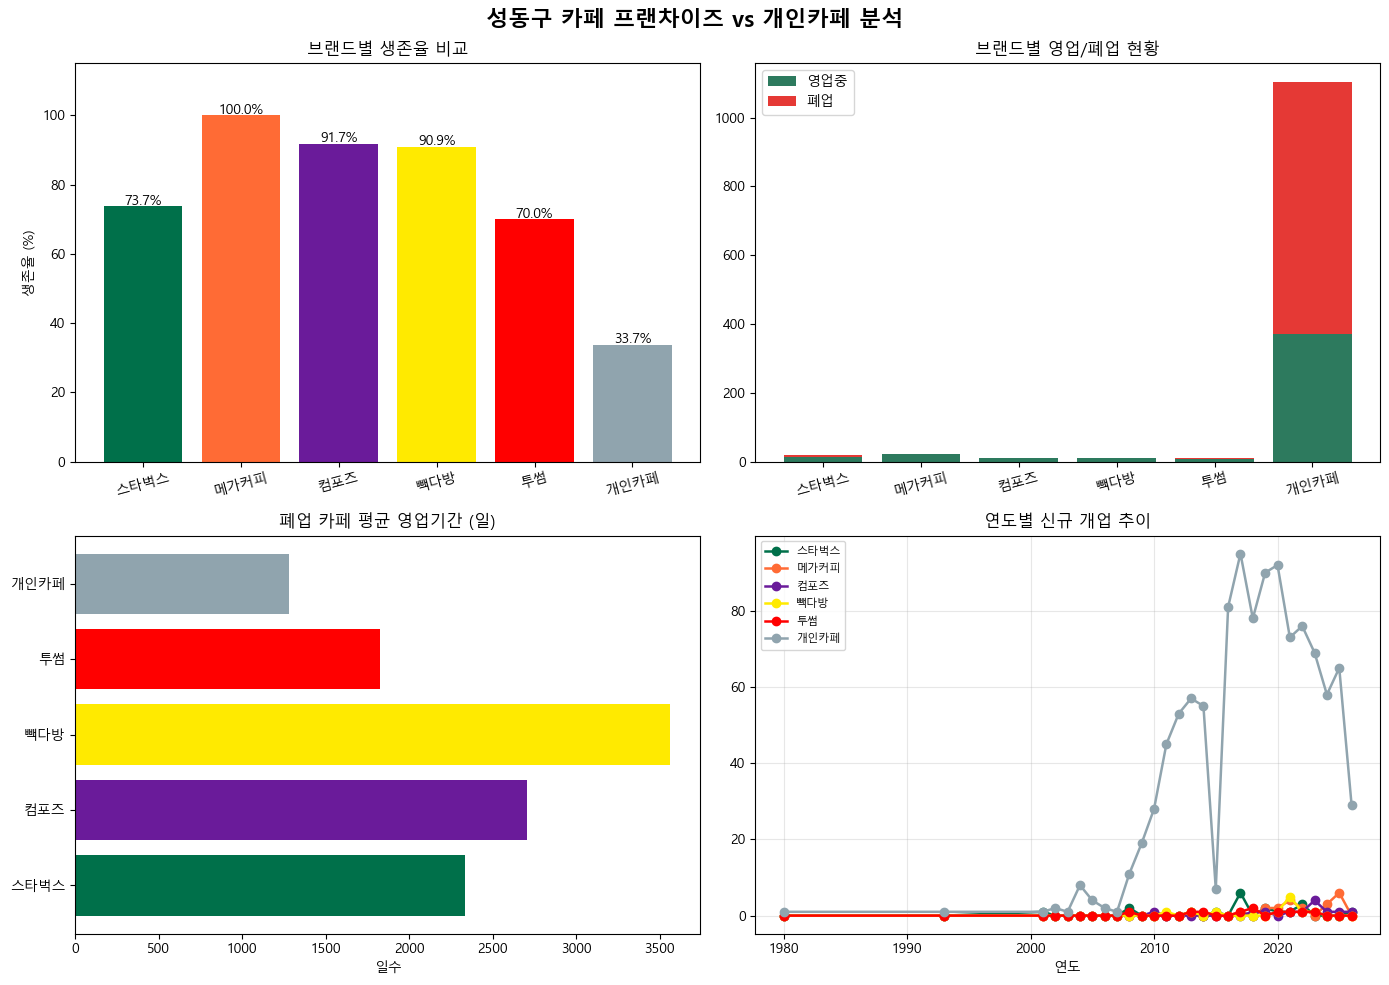

그래프 저장 완료: 성동구_카페_분석.png


In [20]:
colors = {
    '스타벅스': '#00704A',
    '메가커피':  '#FF6B35',
    '컴포즈':   '#6A1B9A',
    '빽다방':   '#FFEA00',
    '투썸':     '#FF0000',
    '개인카페':  '#90A4AE'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('성동구 카페 프랜차이즈 vs 개인카페 분석', fontsize=16, fontweight='bold')

# 그래프 1: 브랜드별 생존율
ax = axes[0][0]
bars = ax.bar(df_result['브랜드'], df_result['생존율(%)'],
              color=[colors[b] for b in df_result['브랜드']])
for bar, val in zip(bars, df_result['생존율(%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10)
ax.set_title('브랜드별 생존율 비교')
ax.set_ylabel('생존율 (%)')
ax.set_ylim(0, 115)
ax.tick_params(axis='x', rotation=15)

# 그래프 2: 영업 vs 폐업 누적 막대
ax = axes[0][1]
x = range(len(df_result))
ax.bar(x, df_result['영업중'], label='영업중', color='#2D7A5E')
ax.bar(x, df_result['폐업'], label='폐업', color='#E53935',
       bottom=df_result['영업중'])
ax.set_xticks(x)
ax.set_xticklabels(df_result['브랜드'], rotation=15)
ax.set_title('브랜드별 영업/폐업 현황')
ax.legend()

# 그래프 3: 평균 영업 기간
ax = axes[1][0]
df_days = df_result.dropna(subset=['평균영업기간(일)'])
ax.barh(df_days['브랜드'], df_days['평균영업기간(일)'],
        color=[colors[b] for b in df_days['브랜드']])
ax.set_title('폐업 카페 평균 영업기간 (일)')
ax.set_xlabel('일수')

# 그래프 4: 연도별 신규 개업 추이
ax = axes[1][1]
data['개업연도'] = data['인허가일자'].dt.year
yearly = data.groupby(['개업연도', '브랜드']).size().unstack(fill_value=0)
for brand in brands:
    if brand in yearly.columns:
        ax.plot(yearly.index, yearly[brand], marker='o',
                color=colors[brand], label=brand, linewidth=1.8)
ax.set_title('연도별 신규 개업 추이')
ax.set_xlabel('연도')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('성동구_카페_분석.png', dpi=150)
plt.show()
print("그래프 저장 완료: 성동구_카페_분석.png")

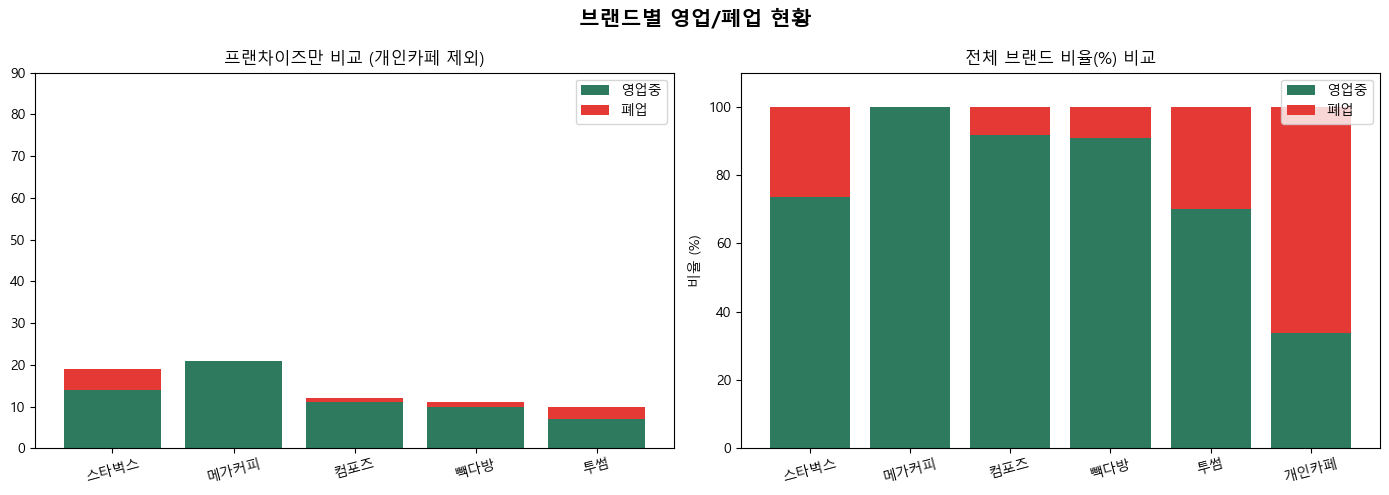

In [19]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

colors = {
    '스타벅스': '#00704A', '메가커피': '#FF6B35',
    '컴포즈': '#6A1B9A', '빽다방': '#FFEA00',
    '투썸': '#FF0000', '개인카페': '#90A4AE'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('브랜드별 영업/폐업 현황', fontsize=15, fontweight='bold')

# ── 그래프 1: 프랜차이즈만 (개인카페 제외) ──
franchise_only = df_result[df_result['브랜드'] != '개인카페']
ax = axes[0]
x = range(len(franchise_only))
ax.bar(x, franchise_only['영업중'], label='영업중', color='#2D7A5E')
ax.bar(x, franchise_only['폐업'], label='폐업', color='#E53935',
       bottom=franchise_only['영업중'].values)
ax.set_xticks(x)
ax.set_xticklabels(franchise_only['브랜드'], rotation=15)
ax.set_ylim(0, 90)  
ax.set_title('프랜차이즈만 비교 (개인카페 제외)')
ax.legend()

# ── 그래프 2: 전체 비율(%) 누적 막대 ──
ax = axes[1]
df_pct = df_result.copy()
df_pct['영업비율'] = df_pct['영업중'] / df_pct['전체'] * 100
df_pct['폐업비율'] = df_pct['폐업']   / df_pct['전체'] * 100

x2 = range(len(df_pct))
ax.bar(x2, df_pct['영업비율'], label='영업중', color='#2D7A5E')
ax.bar(x2, df_pct['폐업비율'], label='폐업', color='#E53935',
       bottom=df_pct['영업비율'].values)
ax.set_xticks(x2)
ax.set_xticklabels(df_pct['브랜드'], rotation=15)
ax.set_ylim(0, 110)
ax.set_ylabel('비율 (%)')
ax.set_title('전체 브랜드 비율(%) 비교')
ax.legend()

plt.tight_layout()
plt.savefig('성동구_영업폐업(개인카페 제외).png', dpi=150)
plt.show()

## 6. 지도 시각화 (folium)

In [16]:
# ✅ 설치 방법 하나로 통일
import sys
!pip install folium

Defaulting to user installation because normal site-packages is not writeable


In [17]:
import folium
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:5181", "EPSG:4326", always_xy=True)

def tm_to_latlon(x, y):
    lon, lat = transformer.transform(float(x), float(y))
    return lat, lon

# ✅ 공백 문자열까지 걸러내는 필터
map_df = data[
    data['좌표정보(X)'].notna() & data['좌표정보(Y)'].notna() &
    (data['좌표정보(X)'].astype(str).str.strip() != '') &
    (data['좌표정보(Y)'].astype(str).str.strip() != '')
].copy()

lats, lons = [], []
for x, y in zip(map_df['좌표정보(X)'], map_df['좌표정보(Y)']):
    lat, lon = tm_to_latlon(x, y)
    lats.append(lat)
    lons.append(lon)

map_df['위도'] = lats
map_df['경도'] = lons

print(f"지도에 표시할 데이터: {len(map_df)}개")
print(map_df[['사업장명', '위도', '경도']].head(3))

ModuleNotFoundError: No module named 'folium'

In [18]:
# 성동구 지도 생성
m = folium.Map(location=[37.4979, 127.0276], zoom_start=13)

color_map = {
    '스타벅스': '#00704A',
    '메가커피':  'orange',
    '컴포즈':   'purple',
    '빽다방':   '#FFEA00',
    '투썸':     '#FF0000',
    '개인카페':  'blue'
}

for _, row in map_df.iterrows():
    try:
        brand  = row['브랜드']
        status = row['상세영업상태명']

        # 폐업 가게는 회색으로 표시
        if status == '폐업':
            pin_color = 'lightgray'
        else:
            pin_color = color_map.get(brand, 'gray')

        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=5,
            color=pin_color,
            fill=True,
            fill_color=pin_color,
            fill_opacity=0.8,
            popup=folium.Popup(f"{row['사업장명']} ({status})", max_width=200)
        ).add_to(m)
    except Exception as e:
        continue

# 범례 추가 (HTML)
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index:1000;
     background: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 13px;">
  <b>브랜드 범례</b><br>
  <span style="color:#00704A">●</span> 스타벅스<br>
  <span style="color:orange">●</span> 메가커피<br>
  <span style="color:purple">●</span> 컴포즈<br>
  <span style="color:#FFEA00">●</span> 빽다방<br>
  <span style="color:#FF0000">●</span> 투썸<br>
  <span style="color:blue">●</span> 개인카페<br>
  <span style="color:lightgray">●</span> 폐업 (전 브랜드)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('성동구_카페_지도.html')
print("지도 저장 완료: 성동구_카페_지도.html")

NameError: name 'folium' is not defined